# Centrality (|ρ| > 0.1)

- Hepatocyte

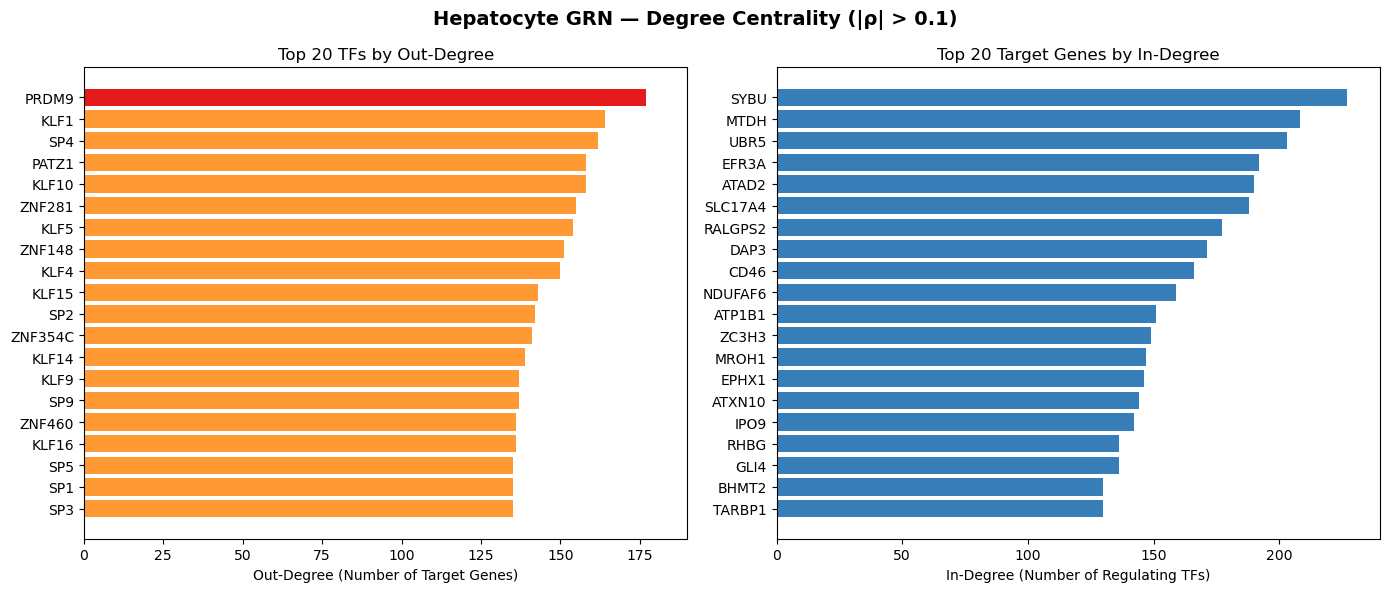

In [22]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/All_GRN_Weights_Hepatocytes.csv')

# 2. 필터링 (|weight| > 0.1)
filtered_df = df[df['grn_weight'].abs() > 0.1].copy()

# 3. 네트워크 그래프 생성
G = nx.DiGraph()
for _, row in filtered_df.iterrows():
    G.add_edge(row['tf_name'], row['gene'], weight=row['grn_weight'])

# 4. Degree Centrality 계산
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

tf_mean_weight = filtered_df.groupby('tf_name')['grn_weight'].apply(lambda x: x.abs().mean()).to_dict()
gene_mean_weight = filtered_df.groupby('gene')['grn_weight'].apply(lambda x: x.abs().mean()).to_dict()

nodes = list(G.nodes())
tfs = set(filtered_df['tf_name'])

centrality_df = pd.DataFrame({
    'node': nodes,
    'in_degree': [in_degree.get(n, 0) for n in nodes],
    'out_degree': [out_degree.get(n, 0) for n in nodes],
    'mean_weight': [tf_mean_weight.get(n, gene_mean_weight.get(n, 0)) for n in nodes],
    'type': ['TF' if n in tfs else 'Target Gene' for n in nodes]
}).sort_values(by=['out_degree', 'mean_weight'], ascending=False)

# 5. Degree Centrality 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (A) TF Out-Degree
tf_df = centrality_df[centrality_df['type'] == 'TF'].head(20)
top_tf = tf_df['node'].iloc[0] if len(tf_df) > 0 else None
second_val = tf_df['out_degree'].iloc[1] if len(tf_df) > 1 else -1
is_unique_top = (tf_df['out_degree'].iloc[0] > second_val) if len(tf_df) > 0 else False
colors_out = ['#E41A1C' if (n == top_tf and is_unique_top) else '#FF9933' for n in tf_df['node']]
axes[0].barh(tf_df['node'][::-1], tf_df['out_degree'][::-1], color=colors_out[::-1])
axes[0].set_xlabel('Out-Degree (Number of Target Genes)')
axes[0].set_title('Top 20 TFs by Out-Degree')
axes[0].set_xlim(0, 190)

# (B) Target Gene In-Degree
gene_df = centrality_df[centrality_df['type'] == 'Target Gene'].sort_values(['in_degree', 'mean_weight'], ascending=False).head(20)
axes[1].barh(gene_df['node'][::-1], gene_df['in_degree'][::-1], color='#377EB8')
axes[1].set_xlabel('In-Degree (Number of Regulating TFs)')
axes[1].set_title('Top 20 Target Genes by In-Degree')
axes[1].set_xlim(0, 240)

plt.suptitle('Hepatocyte GRN — Degree Centrality (|ρ| > 0.1)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

- Mesenchymal

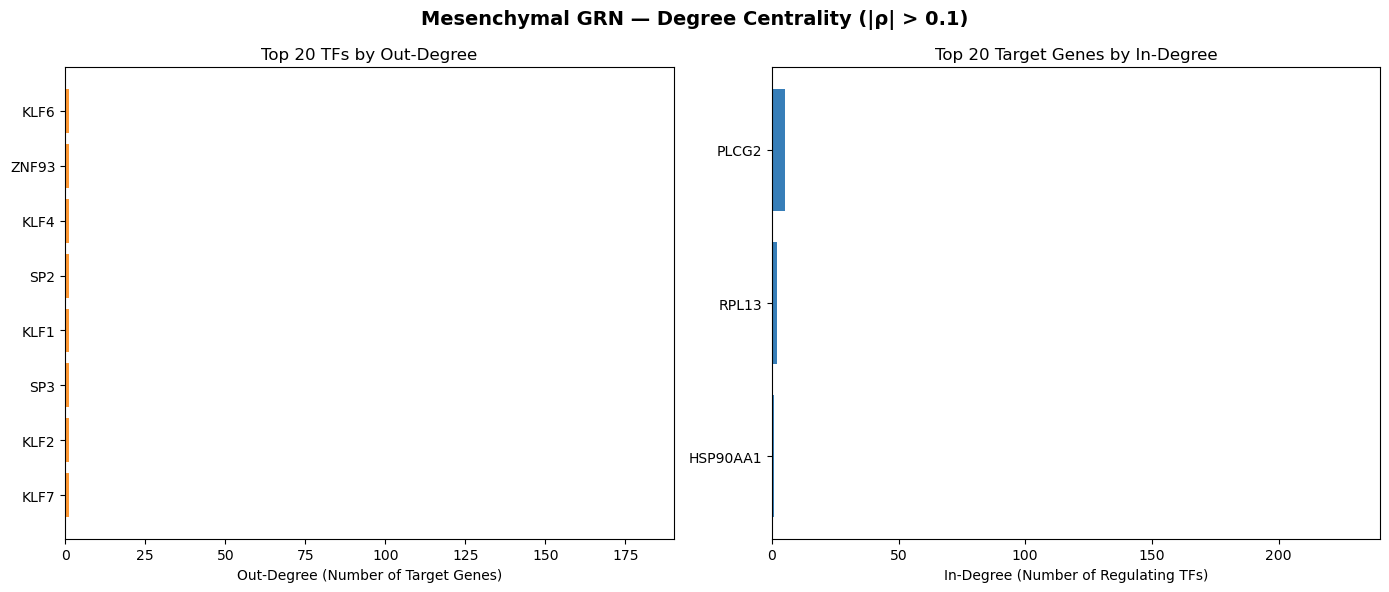

In [23]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/Mesenchymal_All_GRN_Weights.csv')

# 2. 필터링 (|weight| > 0.1)
filtered_df = df[df['grn_weight'].abs() > 0.1].copy()

# 3. 네트워크 그래프 생성
G = nx.DiGraph()
for _, row in filtered_df.iterrows():
    G.add_edge(row['tf_name'], row['gene'], weight=row['grn_weight'])

# 4. Degree Centrality 계산
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

tf_mean_weight = filtered_df.groupby('tf_name')['grn_weight'].apply(lambda x: x.abs().mean()).to_dict()
gene_mean_weight = filtered_df.groupby('gene')['grn_weight'].apply(lambda x: x.abs().mean()).to_dict()

nodes = list(G.nodes())
tfs = set(filtered_df['tf_name'])

centrality_df = pd.DataFrame({
    'node': nodes,
    'in_degree': [in_degree.get(n, 0) for n in nodes],
    'out_degree': [out_degree.get(n, 0) for n in nodes],
    'mean_weight': [tf_mean_weight.get(n, gene_mean_weight.get(n, 0)) for n in nodes],
    'type': ['TF' if n in tfs else 'Target Gene' for n in nodes]
}).sort_values(by=['out_degree', 'mean_weight'], ascending=False)

# 5. Degree Centrality 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (A) TF Out-Degree
tf_df = centrality_df[centrality_df['type'] == 'TF'].head(20)
top_tf = tf_df['node'].iloc[0] if len(tf_df) > 0 else None
second_val = tf_df['out_degree'].iloc[1] if len(tf_df) > 1 else -1
is_unique_top = (tf_df['out_degree'].iloc[0] > second_val) if len(tf_df) > 0 else False
colors_out = ['#E41A1C' if (n == top_tf and is_unique_top) else '#FF9933' for n in tf_df['node']]
axes[0].barh(tf_df['node'][::-1], tf_df['out_degree'][::-1], color=colors_out[::-1])
axes[0].set_xlabel('Out-Degree (Number of Target Genes)')
axes[0].set_title('Top 20 TFs by Out-Degree')
axes[0].set_xlim(0, 190)

# (B) Target Gene In-Degree
gene_df = centrality_df[centrality_df['type'] == 'Target Gene'].sort_values(['in_degree', 'mean_weight'], ascending=False).head(20)
axes[1].barh(gene_df['node'][::-1], gene_df['in_degree'][::-1], color='#377EB8')
axes[1].set_xlabel('In-Degree (Number of Regulating TFs)')
axes[1].set_title('Top 20 Target Genes by In-Degree')
axes[1].set_xlim(0, 240)

plt.suptitle('Mesenchymal GRN — Degree Centrality (|ρ| > 0.1)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
import pandas as pd

df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/Mesenchymal_All_GRN_Weights.csv')
filtered = df[df['grn_weight'].abs() > 0.1].copy()
filtered['|ρ|'] = filtered['grn_weight'].abs()
result = filtered[['tf_name', 'gene', 'grn_weight', '|ρ|']].sort_values('|ρ|', ascending=False).reset_index(drop=True)
result.index = result.index + 1
print(f"Mesenchymal — All TF-Gene edges (|ρ| > 0.1): {len(result)}")
result

Mesenchymal — All TF-Gene edges (|ρ| > 0.1): 8


,tf_name,gene,grn_weight,|ρ|
1,KLF6,RPL13,-0.114821,0.114821
2,ZNF93,HSP90AA1,-0.113974,0.113974
3,KLF4,PLCG2,0.108968,0.108968
4,SP2,PLCG2,0.108404,0.108404
5,KLF1,PLCG2,0.107180,0.107180
6,SP3,PLCG2,0.106673,0.106673
7,KLF2,RPL13,-0.104846,0.104846
8,KLF7,PLCG2,0.100017,0.100017


- Macrophage

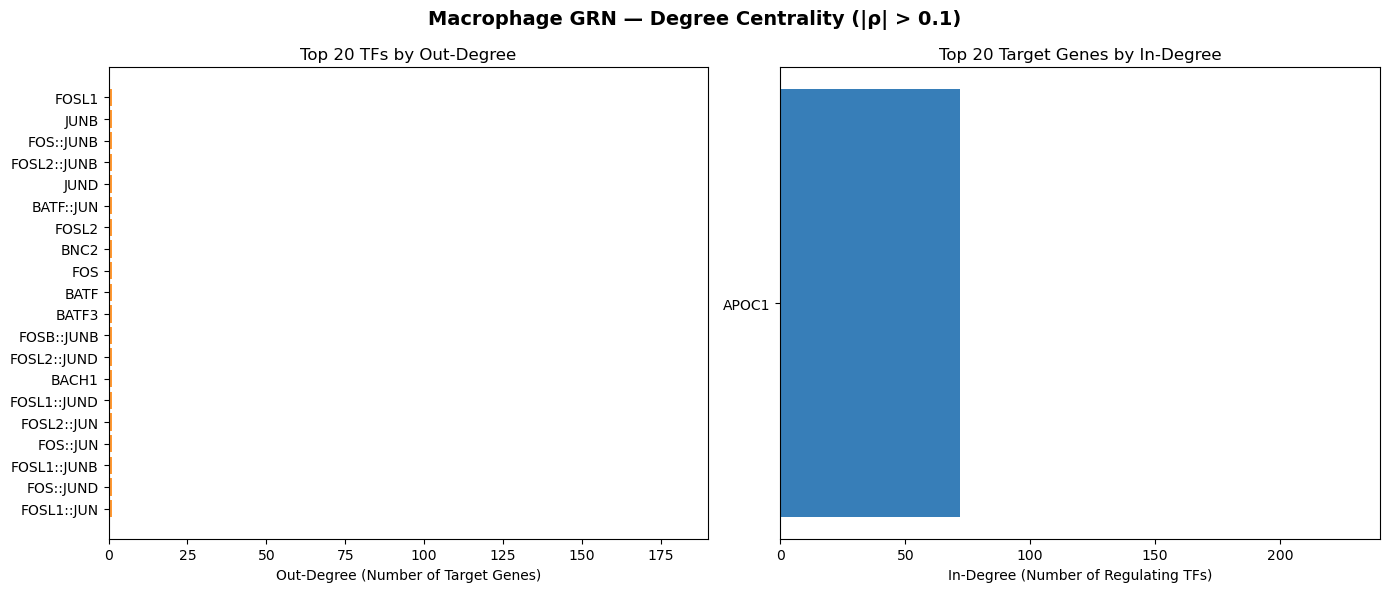

In [25]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/Macrophages_All_GRN_Weights.csv')

# 2. 필터링 (|weight| > 0.1)
filtered_df = df[df['grn_weight'].abs() > 0.1].copy()

if len(filtered_df) == 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax in axes:
        ax.text(0.5, 0.5, 'No edges with |weight| > 0.1', ha='center', va='center', fontsize=12, color='grey', transform=ax.transAxes)
    axes[0].set_title('Top 20 TFs by Out-Degree')
    axes[1].set_title('Top 20 Target Genes by In-Degree')
    axes[0].set_xlim(0, 190)
    axes[1].set_xlim(0, 240)
    plt.suptitle('Macrophage GRN — Degree Centrality (|ρ| > 0.1)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    # 3. 네트워크 그래프 생성
    G = nx.DiGraph()
    for _, row in filtered_df.iterrows():
        G.add_edge(row['tf_name'], row['gene'], weight=row['grn_weight'])

    # 4. Degree Centrality 계산
    in_degree = dict(G.in_degree())
    out_degree = dict(G.out_degree())

    tf_mean_weight = filtered_df.groupby('tf_name')['grn_weight'].apply(lambda x: x.abs().mean()).to_dict()
    gene_mean_weight = filtered_df.groupby('gene')['grn_weight'].apply(lambda x: x.abs().mean()).to_dict()

    nodes = list(G.nodes())
    tfs = set(filtered_df['tf_name'])

    centrality_df = pd.DataFrame({
        'node': nodes,
        'in_degree': [in_degree.get(n, 0) for n in nodes],
        'out_degree': [out_degree.get(n, 0) for n in nodes],
        'mean_weight': [tf_mean_weight.get(n, gene_mean_weight.get(n, 0)) for n in nodes],
        'type': ['TF' if n in tfs else 'Target Gene' for n in nodes]
    }).sort_values(by=['out_degree', 'mean_weight'], ascending=False)

    # 5. Degree Centrality 시각화
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # (A) TF Out-Degree
    tf_df = centrality_df[centrality_df['type'] == 'TF'].head(20)
    top_tf = tf_df['node'].iloc[0] if len(tf_df) > 0 else None
    second_val = tf_df['out_degree'].iloc[1] if len(tf_df) > 1 else -1
    is_unique_top = (tf_df['out_degree'].iloc[0] > second_val) if len(tf_df) > 0 else False
    colors_out = ['#E41A1C' if (n == top_tf and is_unique_top) else '#FF9933' for n in tf_df['node']]
    axes[0].barh(tf_df['node'][::-1], tf_df['out_degree'][::-1], color=colors_out[::-1])
    axes[0].set_xlabel('Out-Degree (Number of Target Genes)')
    axes[0].set_title('Top 20 TFs by Out-Degree')
    axes[0].set_xlim(0, 190)

    # (B) Target Gene In-Degree
    gene_df = centrality_df[centrality_df['type'] == 'Target Gene'].sort_values(['in_degree', 'mean_weight'], ascending=False).head(20)
    axes[1].barh(gene_df['node'][::-1], gene_df['in_degree'][::-1], color='#377EB8')
    axes[1].set_xlabel('In-Degree (Number of Regulating TFs)')
    axes[1].set_title('Top 20 Target Genes by In-Degree')
    axes[1].set_xlim(0, 240)

    plt.suptitle('Macrophage GRN — Degree Centrality (|ρ| > 0.1)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [26]:
import pandas as pd

df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/Macrophages_All_GRN_Weights.csv')
filtered = df[df['grn_weight'].abs() > 0.1].copy()
filtered['|ρ|'] = filtered['grn_weight'].abs()
result = filtered[['tf_name', 'gene', 'grn_weight', '|ρ|']].sort_values('|ρ|', ascending=False).reset_index(drop=True)
result.index = result.index + 1
print(f"Macrophage — All TF-Gene edges (|ρ| > 0.1): {len(result)}")
result

Macrophage — All TF-Gene edges (|ρ| > 0.1): 72


,tf_name,gene,grn_weight,|ρ|
1,FOSL1,APOC1,-0.261451,0.261451
2,JUNB,APOC1,-0.261223,0.261223
3,FOS::JUNB,APOC1,-0.259756,0.259756
4,FOSL2::JUNB,APOC1,-0.259341,0.259341
5,JUND,APOC1,-0.255232,0.255232
...,...,...,...,...
68,PRDM9,APOC1,-0.105584,0.105584
69,PBX3,APOC1,-0.104103,0.104103
70,ZNF320,APOC1,-0.103730,0.103730
71,ZNF449,APOC1,-0.102465,0.102465


- T cell

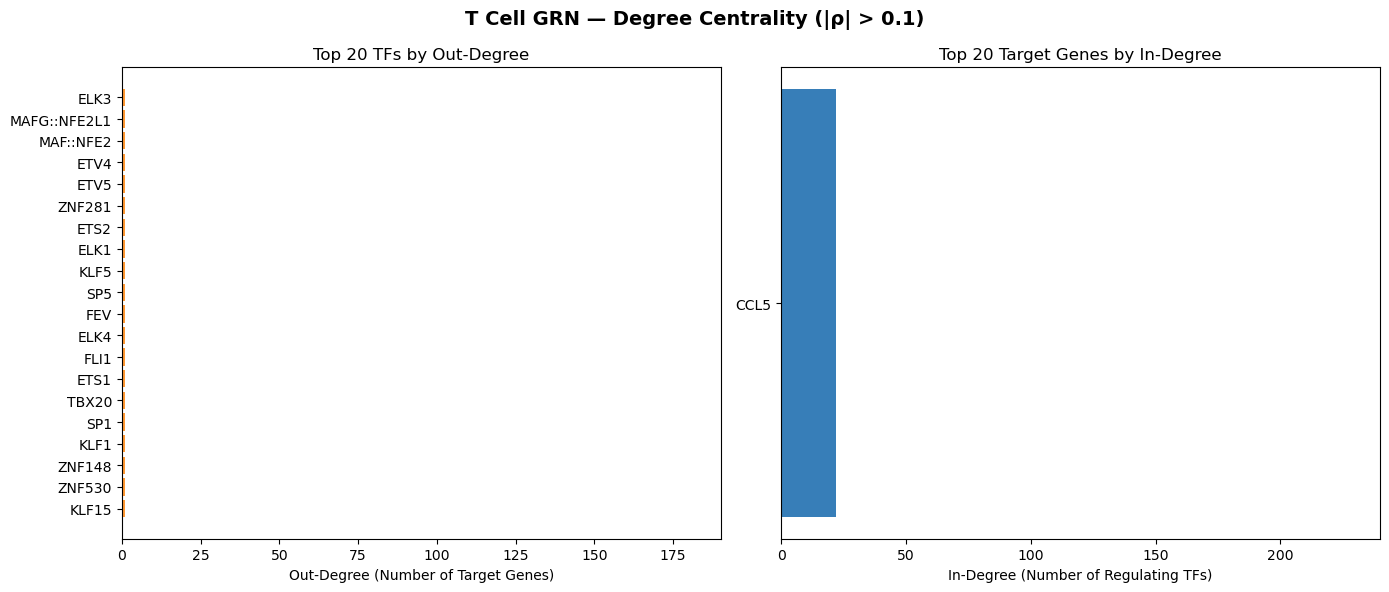

In [27]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/T_Cells_All_GRN_Weights.csv')

# 2. 필터링 (|weight| > 0.1)
filtered_df = df[df['grn_weight'].abs() > 0.1].copy()

# 3. 네트워크 그래프 생성
G = nx.DiGraph()
for _, row in filtered_df.iterrows():
    G.add_edge(row['tf_name'], row['gene'], weight=row['grn_weight'])

# 4. Degree Centrality 계산
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

tf_mean_weight = filtered_df.groupby('tf_name')['grn_weight'].apply(lambda x: x.abs().mean()).to_dict()
gene_mean_weight = filtered_df.groupby('gene')['grn_weight'].apply(lambda x: x.abs().mean()).to_dict()

nodes = list(G.nodes())
tfs = set(filtered_df['tf_name'])

centrality_df = pd.DataFrame({
    'node': nodes,
    'in_degree': [in_degree.get(n, 0) for n in nodes],
    'out_degree': [out_degree.get(n, 0) for n in nodes],
    'mean_weight': [tf_mean_weight.get(n, gene_mean_weight.get(n, 0)) for n in nodes],
    'type': ['TF' if n in tfs else 'Target Gene' for n in nodes]
}).sort_values(by=['out_degree', 'mean_weight'], ascending=False)

# 5. Degree Centrality 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (A) TF Out-Degree
tf_df = centrality_df[centrality_df['type'] == 'TF'].head(20)
top_tf = tf_df['node'].iloc[0] if len(tf_df) > 0 else None
second_val = tf_df['out_degree'].iloc[1] if len(tf_df) > 1 else -1
is_unique_top = (tf_df['out_degree'].iloc[0] > second_val) if len(tf_df) > 0 else False
colors_out = ['#E41A1C' if (n == top_tf and is_unique_top) else '#FF9933' for n in tf_df['node']]
axes[0].barh(tf_df['node'][::-1], tf_df['out_degree'][::-1], color=colors_out[::-1])
axes[0].set_xlabel('Out-Degree (Number of Target Genes)')
axes[0].set_title('Top 20 TFs by Out-Degree')
axes[0].set_xlim(0, 190)

# (B) Target Gene In-Degree
gene_df = centrality_df[centrality_df['type'] == 'Target Gene'].sort_values(['in_degree', 'mean_weight'], ascending=False).head(20)
axes[1].barh(gene_df['node'][::-1], gene_df['in_degree'][::-1], color='#377EB8')
axes[1].set_xlabel('In-Degree (Number of Regulating TFs)')
axes[1].set_title('Top 20 Target Genes by In-Degree')
axes[1].set_xlim(0, 240)

plt.suptitle('T Cell GRN — Degree Centrality (|ρ| > 0.1)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
import pandas as pd

df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/T_Cells_All_GRN_Weights.csv')
filtered = df[df['grn_weight'].abs() > 0.1].copy()
filtered['|ρ|'] = filtered['grn_weight'].abs()
result = filtered[['tf_name', 'gene', 'grn_weight', '|ρ|']].sort_values('|ρ|', ascending=False).reset_index(drop=True)
result.index = result.index + 1
print(f"T Cell — All TF-Gene edges (|ρ| > 0.1): {len(result)}")
result

T Cell — All TF-Gene edges (|ρ| > 0.1): 22


,tf_name,gene,grn_weight,|ρ|
1,ELK3,CCL5,0.150047,0.150047
2,MAFG::NFE2L1,CCL5,-0.140182,0.140182
3,MAF::NFE2,CCL5,-0.136356,0.136356
4,ETV4,CCL5,0.131890,0.131890
5,ETV5,CCL5,0.131767,0.131767
6,ZNF281,CCL5,-0.131653,0.131653
7,ETS2,CCL5,0.129792,0.129792
8,ELK1,CCL5,0.126735,0.126735
9,KLF5,CCL5,-0.123492,0.123492
10,SP5,CCL5,-0.120653,0.120653


- NK Cell

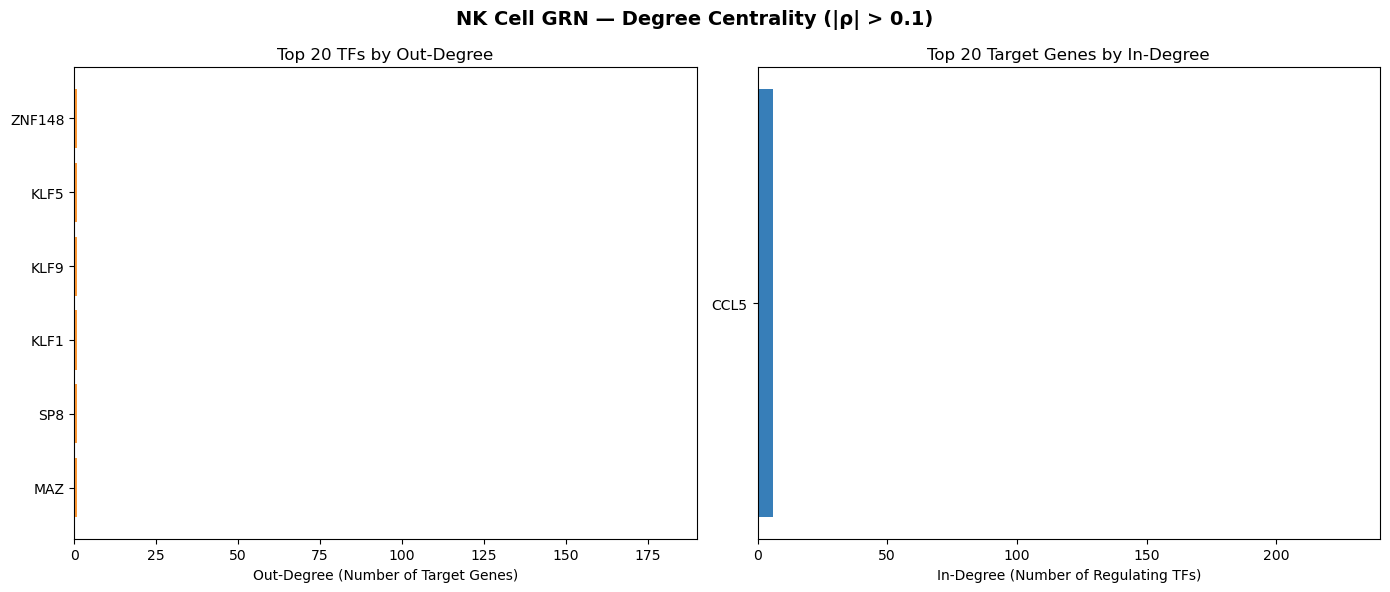

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/NK_Cells_All_GRN_Weights.csv')

# 2. 필터링 (|weight| > 0.1)
filtered_df = df[df['grn_weight'].abs() > 0.1].copy()

if len(filtered_df) == 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax in axes:
        ax.text(0.5, 0.5, 'No edges with |weight| > 0.1', ha='center', va='center', fontsize=12, color='grey', transform=ax.transAxes)
    axes[0].set_title('Top 20 TFs by Out-Degree')
    axes[1].set_title('Top 20 Target Genes by In-Degree')
    axes[0].set_xlim(0, 190)
    axes[1].set_xlim(0, 240)
    plt.suptitle('NK Cell GRN — Degree Centrality (|ρ| > 0.1)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    # 3. 네트워크 그래프 생성
    G = nx.DiGraph()
    for _, row in filtered_df.iterrows():
        G.add_edge(row['tf_name'], row['gene'], weight=row['grn_weight'])

    # 4. Degree Centrality 계산
    in_degree = dict(G.in_degree())
    out_degree = dict(G.out_degree())

    tf_mean_weight = filtered_df.groupby('tf_name')['grn_weight'].apply(lambda x: x.abs().mean()).to_dict()
    gene_mean_weight = filtered_df.groupby('gene')['grn_weight'].apply(lambda x: x.abs().mean()).to_dict()

    nodes = list(G.nodes())
    tfs = set(filtered_df['tf_name'])

    centrality_df = pd.DataFrame({
        'node': nodes,
        'in_degree': [in_degree.get(n, 0) for n in nodes],
        'out_degree': [out_degree.get(n, 0) for n in nodes],
        'mean_weight': [tf_mean_weight.get(n, gene_mean_weight.get(n, 0)) for n in nodes],
        'type': ['TF' if n in tfs else 'Target Gene' for n in nodes]
    }).sort_values(by=['out_degree', 'mean_weight'], ascending=False)

    # 5. Degree Centrality 시각화
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # (A) TF Out-Degree
    tf_df = centrality_df[centrality_df['type'] == 'TF'].head(20)
    top_tf = tf_df['node'].iloc[0] if len(tf_df) > 0 else None
    second_val = tf_df['out_degree'].iloc[1] if len(tf_df) > 1 else -1
    is_unique_top = (tf_df['out_degree'].iloc[0] > second_val) if len(tf_df) > 0 else False
    colors_out = ['#E41A1C' if (n == top_tf and is_unique_top) else '#FF9933' for n in tf_df['node']]
    axes[0].barh(tf_df['node'][::-1], tf_df['out_degree'][::-1], color=colors_out[::-1])
    axes[0].set_xlabel('Out-Degree (Number of Target Genes)')
    axes[0].set_title('Top 20 TFs by Out-Degree')
    axes[0].set_xlim(0, 190)

    # (B) Target Gene In-Degree
    gene_df = centrality_df[centrality_df['type'] == 'Target Gene'].sort_values(['in_degree', 'mean_weight'], ascending=False).head(20)
    axes[1].barh(gene_df['node'][::-1], gene_df['in_degree'][::-1], color='#377EB8')
    axes[1].set_xlabel('In-Degree (Number of Regulating TFs)')
    axes[1].set_title('Top 20 Target Genes by In-Degree')
    axes[1].set_xlim(0, 240)

    plt.suptitle('NK Cell GRN — Degree Centrality (|ρ| > 0.1)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [3]:
import pandas as pd

df = pd.read_csv('/data1/project/yeonu/065_multi_atac/GRN/results_output/NK_Cells_All_GRN_Weights.csv')
filtered = df[df['grn_weight'].abs() > 0.1].copy()
filtered['|ρ|'] = filtered['grn_weight'].abs()
result = filtered[['tf_name', 'gene', 'grn_weight', '|ρ|']].sort_values('|ρ|', ascending=False).reset_index(drop=True)
result.index = result.index + 1
print(f"NK Cell — All TF-Gene edges (|ρ| > 0.1): {len(result)}")
result

NK Cell — All TF-Gene edges (|ρ| > 0.1): 6


,tf_name,gene,grn_weight,|ρ|
1,ZNF148,CCL5,-0.135406,0.135406
2,KLF5,CCL5,-0.113762,0.113762
3,KLF9,CCL5,-0.104300,0.104300
4,KLF1,CCL5,-0.102342,0.102342
5,SP8,CCL5,-0.101908,0.101908
6,MAZ,CCL5,-0.101157,0.101157
